# Beyond Accuracy: A Decision-Impact Analysis of Sentiment Classification Errors




## 1. Environment Setup
###  Import libraries


###  Core imports and package loading


In [ ]:
import bz2
import os
import random
import seaborn as sns
import re
import warnings
from functools import reduce
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from datasets import Dataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import time
import gc

###  Project folders and working directories


In [ ]:
FOLDERS = ["data", "results", "errors", "figures", "tables", "models"]
for f in FOLDERS:
    os.makedirs(f, exist_ok=True)

print("✅ Created folders:", FOLDERS)


✅ Created folders: ['data', 'results', 'errors', 'figures', 'tables', 'models']


## 2. Reproducibility and Global Settings
###  Fixed settings and random seeds


###  Random seed definition


In [ ]:
RANDOM_SEED = 42

# IMPORTANT:
USE_GIVEN_TRAIN_TEST = True

MODEL_LIST = ["LR", "NB", "RF", "BERT"]

TFIDF_MAX_FEATURES = 50000
TFIDF_NGRAM_RANGE = (1, 2)
TFIDF_MIN_DF = 2

RF_N_ESTIMATORS = 300
RF_MAX_DEPTH = None

BERT_MODEL_NAME = "distilbert-base-uncased"
BERT_EPOCHS = 2
BERT_BATCH_SIZE = 16
BERT_MAX_LENGTH = 256
BERT_LR = 2e-5
BERT_WEIGHT_DECAY = 0.01

print("✅ Fixed settings loaded.")
print("USE_GIVEN_TRAIN_TEST =", USE_GIVEN_TRAIN_TEST)
print("Models:", MODEL_LIST)


✅ Fixed settings loaded.
USE_GIVEN_TRAIN_TEST = True
Models: ['LR', 'NB', 'RF', 'BERT']


###  Seed application across libraries


In [ ]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

try:
    torch.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed_all(RANDOM_SEED)
except Exception:
    pass

print("✅ Random seed applied.")


✅ Random seed applied.


## 3. Data Ingestion
###  Load Amazon Reviews data in fastText format


###  fastText reader utility


In [ ]:
def read_fasttext_bz2(path: str, label_prefix="__label__") -> pd.DataFrame:
    """
    Reads FastText supervised format:
      __label__X some text...
    Returns DataFrame with columns: label_raw, text
    """
    labels = []
    texts = []

    with bz2.open(path, "rt", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split(" ", 1)
            if len(parts) < 2:
                continue

            lab, txt = parts[0], parts[1].strip()
            if not lab.startswith(label_prefix):
                continue

            labels.append(lab)
            texts.append(txt)

    return pd.DataFrame({"label_raw": labels, "text": texts})

dataset_path = kagglehub.dataset_download("bittlingmayer/amazonreviews")
print("Dataset downloaded to:", dataset_path)

files = os.listdir(dataset_path)
print("Files found:", files)

train_file = os.path.join(dataset_path, "train.ft.txt.bz2")
test_file  = os.path.join(dataset_path, "test.ft.txt.bz2")

df_train_raw = read_fasttext_bz2(train_file)
df_test_raw  = read_fasttext_bz2(test_file)

def normalize_fasttext_label_number(lab: str) -> str:
    return lab.replace("__label__", "").strip().lower()

df_train_raw["label"] = df_train_raw["label_raw"].map(normalize_fasttext_label_number)
df_test_raw["label"]  = df_test_raw["label_raw"].map(normalize_fasttext_label_number)

label_map = {"1": "Negative", "2": "Positive"}
train_df = df_train_raw.copy()
test_df = df_test_raw.copy()
train_df["sentiment"] = train_df["label"].map(label_map)
test_df["sentiment"]  = test_df["label"].map(label_map)

train_df = train_df[["text", "sentiment"]]
test_df = test_df[["text", "sentiment"]]

print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain sample:")
display(train_df.head())

print("\nTest sample:")
display(test_df.head())

100%|██████████| 493M/493M [00:02<00:00, 184MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/bittlingmayer/amazonreviews/versions/7
Files found: ['train.ft.txt.bz2', 'test.ft.txt.bz2']

Train shape: (3600000, 2)
Test shape: (400000, 2)

Train sample:


,text,sentiment
0,Stuning even for the non-gamer: This sound tra...,Positive
1,The best soundtrack ever to anything.: I'm rea...,Positive
2,Amazing!: This soundtrack is my favorite music...,Positive
3,Excellent Soundtrack: I truly like this soundt...,Positive
4,"Remember, Pull Your Jaw Off The Floor After He...",Positive



Test sample:


,text,sentiment
0,Great CD: My lovely Pat has one of the GREAT v...,Positive
1,One of the best game music soundtracks - for a...,Positive
2,Batteries died within a year ...: I bought thi...,Negative
3,"works fine, but Maha Energy is better: Check o...",Positive
4,Great for the non-audiophile: Reviewed quite a...,Positive


###  Training and test dataset overview


In [ ]:
print("TRAIN shape:", df_train_raw.shape)
print("TRAIN columns:", df_train_raw.columns.tolist())
print("\nTEST shape:", df_test_raw.shape)
print("TEST columns:", df_test_raw.columns.tolist())


TRAIN shape: (3600000, 3)
TRAIN columns: ['label_raw', 'text', 'label']

TEST shape: (400000, 3)
TEST columns: ['label_raw', 'text', 'label']


In [ ]:
print("TRAIN missing values:\n", df_train_raw.isnull().sum())
print("\nTEST missing values:\n", df_test_raw.isnull().sum())


TRAIN missing values:
 label_raw    0
text         0
label        0
dtype: int64

TEST missing values:
 label_raw    0
text         0
label        0
dtype: int64


In [ ]:
train_dup = df_train_raw.duplicated().sum()
test_dup  = df_test_raw.duplicated().sum()

print("Duplicate rows:")
print(" - Train duplicates:", train_dup)
print(" - Test duplicates:", test_dup)


Duplicate rows:
 - Train duplicates: 0
 - Test duplicates: 0


## 4. Data Audit and Cleaning
###  Initial data quality checks and cleaning pipeline


###  Create working copies for downstream processing


In [ ]:
df_train = df_train_raw[["text", "label_raw"]].copy()
df_test  = df_test_raw[["text", "label_raw"]].copy()

print("✅ Kept required columns only.")
print("Train:", df_train.shape, "| Test:", df_test.shape)


✅ Kept required columns only.
Train: (3600000, 2) | Test: (400000, 2)


###  Cleaning and audit helper functions


In [ ]:
def clean_and_audit(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    initial = len(df)

    df = df.dropna(subset=["text", "label_raw"]).copy()
    df["text"] = df["text"].astype(str).str.strip()
    df["label_raw"] = df["label_raw"].astype(str).str.strip()
    df = df[(df["text"] != "") & (df["label_raw"] != "")].copy()
    after_missing = len(df)

    df = df.drop_duplicates().copy()
    final = len(df)

    audit = {
        "initial_rows": initial,
        "missing_removed": initial - after_missing,
        "duplicates_removed": after_missing - final,
        "final_rows": final
    }
    return df.reset_index(drop=True), audit

df_train, audit_train = clean_and_audit(df_train)
df_test, audit_test   = clean_and_audit(df_test)

print("✅ Cleaning completed.")
print("Train audit:", audit_train)
print("Test audit:", audit_test)


✅ Cleaning completed.
Train audit: {'initial_rows': 3600000, 'missing_removed': 0, 'duplicates_removed': 0, 'final_rows': 3600000}
Test audit: {'initial_rows': 400000, 'missing_removed': 0, 'duplicates_removed': 0, 'final_rows': 400000}


In [ ]:
def normalize_fasttext_label(lab: str) -> str:
    lab = lab.replace("__label__", "").strip().lower()
    return lab

df_train["label"] = df_train["label_raw"].map(normalize_fasttext_label)
df_test["label"]  = df_test["label_raw"].map(normalize_fasttext_label)

print("Unique labels (train):", sorted(df_train["label"].unique().tolist()))
print("Unique labels (test):", sorted(df_test["label"].unique().tolist()))


Unique labels (train): ['1', '2']
Unique labels (test): ['1', '2']


###  Dataset overview table generation


In [ ]:
table1 = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Original rows": [audit_train["initial_rows"], audit_test["initial_rows"]],
    "Missing texts removed": [audit_train["missing_removed"], audit_test["missing_removed"]],
    "Duplicates removed": [audit_train["duplicates_removed"], audit_test["duplicates_removed"]],
    "Final usable rows": [audit_train["final_rows"], audit_test["final_rows"]],
    "Text column": ["text", "text"],
    "Label column": ["label", "label"]
})

table1.to_csv("tables/Table1_Dataset_Overview.csv", index=False)
table1


,Split,Original rows,Missing texts removed,Duplicates removed,Final usable rows,Text column,Label column
0,Train,3600000,0,0,3600000,text,label
1,Test,400000,0,0,400000,text,label


In [ ]:
df_train[["text", "label"]].to_csv("data/cleaned_train.csv", index=False)
df_test[["text", "label"]].to_csv("data/cleaned_test.csv", index=False)

print("✅ Saved:")
print(" - data/cleaned_train.csv")
print(" - data/cleaned_test.csv")


✅ Saved:
 - data/cleaned_train.csv
 - data/cleaned_test.csv


## 5. Label Normalization and Binary Sentiment Targets



###  Sentiment target creation


In [ ]:
df_train["sentiment"] = df_train["label"]
df_test["sentiment"] = df_test["label"]

df_train = df_train.drop(columns=["label"])
df_test = df_test.drop(columns=["label"])

print("✅ Sentiment column created.")
print("Train sentiments:", df_train["sentiment"].unique())
print("Test sentiments:", df_test["sentiment"].unique())


✅ Sentiment column created.
Train sentiments: ['2' '1']
Test sentiments: ['2' '1']


In [ ]:
train_counts = df_train["sentiment"].value_counts()
test_counts = df_test["sentiment"].value_counts()

print("Train class counts:")
print(train_counts)

print("\nTest class counts:")
print(test_counts)


Train class counts:
sentiment
2    1800000
1    1800000
Name: count, dtype: int64

Test class counts:
sentiment
2    200000
1    200000
Name: count, dtype: int64


In [ ]:
train_percent = (train_counts / train_counts.sum() * 100).round(2)
test_percent = (test_counts / test_counts.sum() * 100).round(2)

print("Train class percentages (%):")
print(train_percent)

print("\nTest class percentages (%):")
print(test_percent)


Train class percentages (%):
sentiment
2    50.0
1    50.0
Name: count, dtype: float64

Test class percentages (%):
sentiment
2    50.0
1    50.0
Name: count, dtype: float64


###  Label distribution summary table


In [ ]:
table2 = pd.DataFrame({
    "Sentiment": train_counts.index,
    "Train_Count": train_counts.values,
    "Train_Percentage (%)": train_percent.values,
    "Test_Count": test_counts.reindex(train_counts.index).values,
    "Test_Percentage (%)": test_percent.reindex(train_counts.index).values
})

table2.to_csv("tables/Table2_Class_Distribution.csv", index=False)
table2


,Sentiment,Train_Count,Train_Percentage (%),Test_Count,Test_Percentage (%)
0,2,1800000,50.0,200000,50.0
1,1,1800000,50.0,200000,50.0


## 6. Exploratory Data Analysis (EDA)



###  Review-length feature engineering


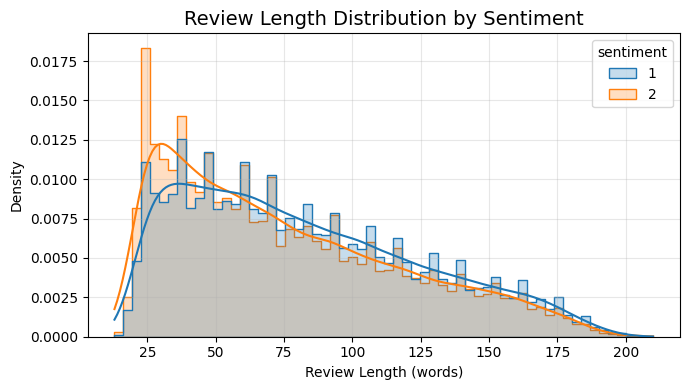

In [ ]:
# create length feature
df_train["review_length"] = df_train["text"].fillna("").astype(str).str.count(r"\S+")

plt.figure(figsize=(7,4))

sns.histplot(
    data=df_train.sample(n=min(50000, len(df_train)), random_state=42),
    x="review_length",
    hue="sentiment",
    bins=60,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Review Length Distribution by Sentiment", fontsize=14)
plt.xlabel("Review Length (words)")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Longer reviews tend to contain mixed opinions and contextual complexity, which increases classification difficulty. Differences in review length distribution may therefore introduce model bias.


###  Distribution analysis and sampling for visualization


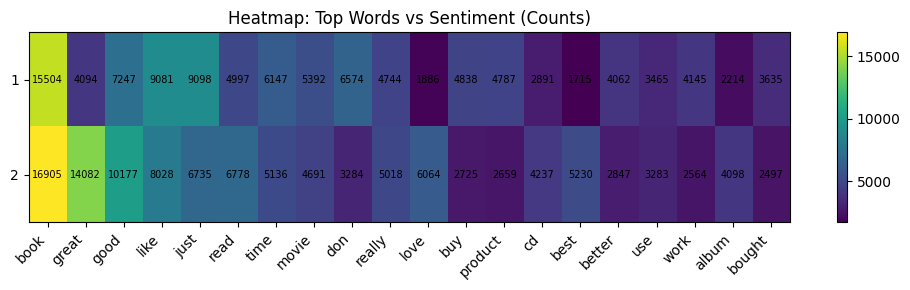

In [ ]:
df_sample = df_train.sample(n=min(60000, len(df_train)), random_state=42)

vec = CountVectorizer(stop_words="english", max_features=30000)
X = vec.fit_transform(df_sample["text"].fillna("").astype(str))
vocab = np.array(vec.get_feature_names_out())

# Get top words overall
total_counts = X.sum(axis=0).A1
top_idx = np.argsort(total_counts)[-20:][::-1]
top_words = vocab[top_idx]

labels = sorted(df_sample["sentiment"].unique())
mat = []
for lab in labels:
    mask = (df_sample["sentiment"] == lab).values
    counts = X[mask].sum(axis=0).A1[top_idx]
    mat.append(counts)

mat = np.array(mat)

plt.figure(figsize=(10,3))
plt.imshow(mat, aspect="auto")
plt.title("Heatmap: Top Words vs Sentiment (Counts)")
plt.colorbar()

plt.xticks(range(len(top_words)), top_words, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(top_words)):
        plt.text(j, i, int(mat[i, j]), ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.savefig("figures/EDA_TopWords_Sentiment_Heatmap.png", dpi=200)
plt.show()


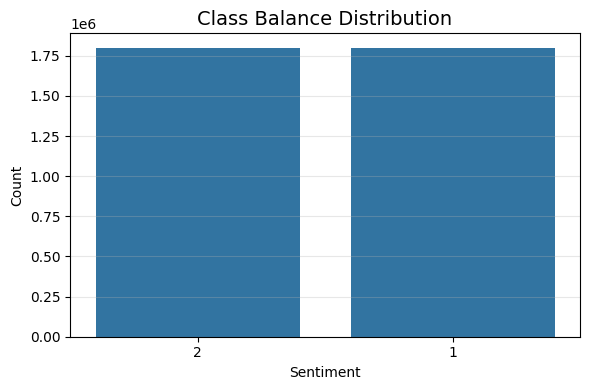

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_train, x="sentiment")
plt.title("Class Balance Distribution", fontsize=14)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The dataset exhibits balanced class distribution, minimizing majority-class bias and ensuring fair model evaluation.

## 7. Classical NLP Preprocessing
### Text preprocessing and TF–IDF feature construction


###  Sampling, vectorization, and shared evaluation utilities


In [ ]:
SAMPLE_N = 100_000
SAMPLE_N = min(SAMPLE_N, len(df_train))

df_train_small, _ = train_test_split(
    df_train,
    train_size=SAMPLE_N,
    stratify=df_train["sentiment"],
    random_state=RANDOM_SEED
)

# --- Create 'text_clean' column ---
df_train_small["text_clean"] = df_train_small["text"].str.lower().str.strip()
df_test["text_clean"] = df_test["text"].str.lower().str.strip()

tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 1),
    min_df=3,
    dtype=np.float32,
    lowercase=False
)

X_train_tfidf = tfidf_vectorizer.fit_transform(df_train_small["text_clean"])
X_test_tfidf  = tfidf_vectorizer.transform(df_test["text_clean"])

y_train = df_train_small["sentiment"].values
y_test  = df_test["sentiment"].values

labels_sorted = sorted(df_test["sentiment"].unique().tolist())

print("✅ TF–IDF created.")
print("Train TF-IDF:", X_train_tfidf.shape)
print("Test TF-IDF:", X_test_tfidf.shape)
print("Labels:", labels_sorted)

✅ TF–IDF created.
Train TF-IDF: (100000, 20000)
Test TF-IDF: (400000, 20000)
Labels: ['1', '2']


In [ ]:
def compute_metrics(y_true, y_pred, labels):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred,
        labels=labels,
        average="macro",
        zero_division=0
    )
    return {
        "accuracy": float(acc),
        "precision_macro": float(p),
        "recall_macro": float(r),
        "f1_macro": float(f1)
    }

def save_confusion_matrix(y_true, y_pred, labels, out_path):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{l}" for l in labels],
        columns=[f"pred_{l}" for l in labels]
    )
    cm_df.to_csv(out_path, index=True)
    return cm_df


## 8. Tier 2 Baseline Models
###  Logistic Regression, Naive Bayes, and Random Forest training


###  Logistic Regression training and prediction export


In [ ]:
lr = LogisticRegression(max_iter=2000, n_jobs=-1, class_weight="balanced")
lr.fit(X_train_tfidf, y_train)

pred_lr = lr.predict(X_test_tfidf)

metrics_lr = compute_metrics(y_test, pred_lr, labels_sorted)
metrics_lr


{'accuracy': 0.89644,
 'precision_macro': 0.8964402537217624,
 'recall_macro': 0.8964399999999999,
 'f1_macro': 0.8964399834303973}

In [ ]:
pred_lr_df = pd.DataFrame({
    "text": df_test["text"].astype(str).values,
    "true_label": y_test,
    "pred_label": pred_lr
})
pred_lr_df.to_csv("results/pred_lr.csv", index=False)

cm_lr = save_confusion_matrix(y_test, pred_lr, labels_sorted, "tables/CM_LR.csv")
cm_lr


,pred_1,pred_2
true_1,179208,20792
true_2,20632,179368


###  Naive Bayes training and prediction export


In [ ]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

pred_nb = nb.predict(X_test_tfidf)

metrics_nb = compute_metrics(y_test, pred_nb, labels_sorted)
metrics_nb


{'accuracy': 0.8457625,
 'precision_macro': 0.8459232221642836,
 'recall_macro': 0.8457625,
 'f1_macro': 0.8457445825381483}

In [ ]:
pred_nb_df = pd.DataFrame({
    "text": df_test["text"].astype(str).values,
    "true_label": y_test,
    "pred_label": pred_nb
})
pred_nb_df.to_csv("results/pred_nb.csv", index=False)

cm_nb = save_confusion_matrix(y_test, pred_nb, labels_sorted, "tables/CM_NB.csv")
cm_nb


,pred_1,pred_2
true_1,171308,28692
true_2,33003,166997


###  Random Forest training and prediction export


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_depth=None
)

rf.fit(X_train_tfidf, y_train)

pred_rf = rf.predict(X_test_tfidf)

metrics_rf = compute_metrics(y_test, pred_rf, labels_sorted)
metrics_rf


{'accuracy': 0.8655375,
 'precision_macro': 0.866069028944558,
 'recall_macro': 0.8655375000000001,
 'f1_macro': 0.8654886726899962}

In [ ]:
pred_rf_df = pd.DataFrame({
    "text": df_test["text"].astype(str).values,
    "true_label": y_test,
    "pred_label": pred_rf
})
pred_rf_df.to_csv("results/pred_rf.csv", index=False)

cm_rf = save_confusion_matrix(y_test, pred_rf, labels_sorted, "tables/CM_RF.csv")
cm_rf


,pred_1,pred_2
true_1,176918,23082
true_2,30703,169297


###  Baseline metrics and confusion-matrix table construction


In [ ]:
table3 = pd.DataFrame([
    {"Model": "Logistic Regression", **metrics_lr},
    {"Model": "Naive Bayes", **metrics_nb},
    {"Model": "Random Forest", **metrics_rf},
])

table3.to_csv("tables/Table3_Baseline_Metrics.csv", index=False)
table3


,Model,accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression,0.896440,0.896440,0.896440,0.896440
1,Naive Bayes,0.845762,0.845923,0.845762,0.845745
2,Random Forest,0.865537,0.866069,0.865538,0.865489


In [ ]:
table4_index = pd.DataFrame({
    "Model": ["LR", "NB", "RF"],
    "ConfusionMatrixFile": ["tables/CM_LR.csv", "tables/CM_NB.csv", "tables/CM_RF.csv"]
})

table4_index.to_csv("tables/Table4_ConfusionMatrix_Index.csv", index=False)
table4_index


,Model,ConfusionMatrixFile
0,LR,tables/CM_LR.csv
1,NB,tables/CM_NB.csv
2,RF,tables/CM_RF.csv


## 9. Tier 3 Transformer Baseline
###  BERT training, inference, and evaluation


In [ ]:
warnings.filterwarnings("ignore", message="Detected no triton, on systems without Triton certain kernels will not work", category=UserWarning, module="torchao.kernel.intmm")


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

labels_sorted = sorted(pd.Series(df_train["sentiment"]).unique().tolist())
label2id = {l: i for i, l in enumerate(labels_sorted)}
id2label = {i: l for l, i in label2id.items()}

print("Labels:", labels_sorted)
print("label2id:", label2id)

Labels: ['1', '2']
label2id: {'1': 0, '2': 1}


###  Prepare transformer training and evaluation datasets


In [ ]:
train_df = df_train[["text", "sentiment"]].copy()
test_df  = df_test[["text", "sentiment"]].copy()

MAX_TRAIN_ROWS = 20000
if MAX_TRAIN_ROWS is not None and len(train_df) > MAX_TRAIN_ROWS:
    train_df = train_df.sample(MAX_TRAIN_ROWS, random_state=RANDOM_SEED).reset_index(drop=True)

train_df2, val_df = train_test_split(
    train_df,
    test_size=0.10,
    random_state=RANDOM_SEED,
    stratify=train_df["sentiment"]
)

ds_train = Dataset.from_pandas(train_df2.reset_index(drop=True))
ds_val   = Dataset.from_pandas(val_df.reset_index(drop=True))
ds_test  = Dataset.from_pandas(test_df.reset_index(drop=True))

print("Train:", len(ds_train), "Val:", len(ds_val), "Test:", len(ds_test))


Train: 18000 Val: 2000 Test: 400000


###  Tokenizer initialization


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=BERT_MAX_LENGTH
    )

ds_train = ds_train.map(tokenize, batched=True)
ds_val   = ds_val.map(tokenize, batched=True)
ds_test  = ds_test.map(tokenize, batched=True)

def encode_labels(batch):
    batch["labels"] = [label2id[x] for x in batch["sentiment"]]
    return batch

ds_train = ds_train.map(encode_labels, batched=True)
ds_val   = ds_val.map(encode_labels, batched=True)
ds_test  = ds_test.map(encode_labels, batched=True)

keep_cols = ["input_ids", "attention_mask", "labels"]
ds_train = ds_train.remove_columns([c for c in ds_train.column_names if c not in keep_cols])
ds_val   = ds_val.remove_columns([c for c in ds_val.column_names if c not in keep_cols])
ds_test  = ds_test.remove_columns([c for c in ds_test.column_names if c not in keep_cols])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("✅ Tokenization complete.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/400000 [00:00<?, ? examples/s]

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/400000 [00:00<?, ? examples/s]

✅ Tokenization complete.


In [ ]:
def compute_metrics_hf(eval_pred):
    logits, y_true = eval_pred
    y_pred = np.argmax(logits, axis=-1)

    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )
    return {
        "accuracy": float(acc),
        "precision_macro": float(p),
        "recall_macro": float(r),
        "f1_macro": float(f1)
    }


###  Model initialization and fine-tuning


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=len(labels_sorted),
    label2id=label2id,
    id2label=id2label
)

training_args = TrainingArguments(
    output_dir="models/bert_checkpoints",
    learning_rate=BERT_LR,
    per_device_train_batch_size=BERT_BATCH_SIZE,
    per_device_eval_batch_size=BERT_BATCH_SIZE,
    num_train_epochs=BERT_EPOCHS,
    weight_decay=BERT_WEIGHT_DECAY,
    eval_strategy="epoch",
    load_best_model_at_end=False, # Set to False as evaluation strategy is not active
    report_to="none",
    seed=RANDOM_SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics_hf
)

trainer.train()
print("✅ BERT training complete.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.266257
1000,0.193280
1500,0.126436
2000,0.102259


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ BERT training complete.


### Model Performance Comparison (F1-Macro Score)

This bar chart compares the F1-macro scores across all models, providing a quick overview of their overall performance in sentiment classification. Higher F1-macro indicates better balance between precision and recall for both classes.

/tmp/ipykernel_1453/4269666105.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='f1_macro', data=table3_updated.sort_values(by='f1_macro', ascending=False), palette='viridis')


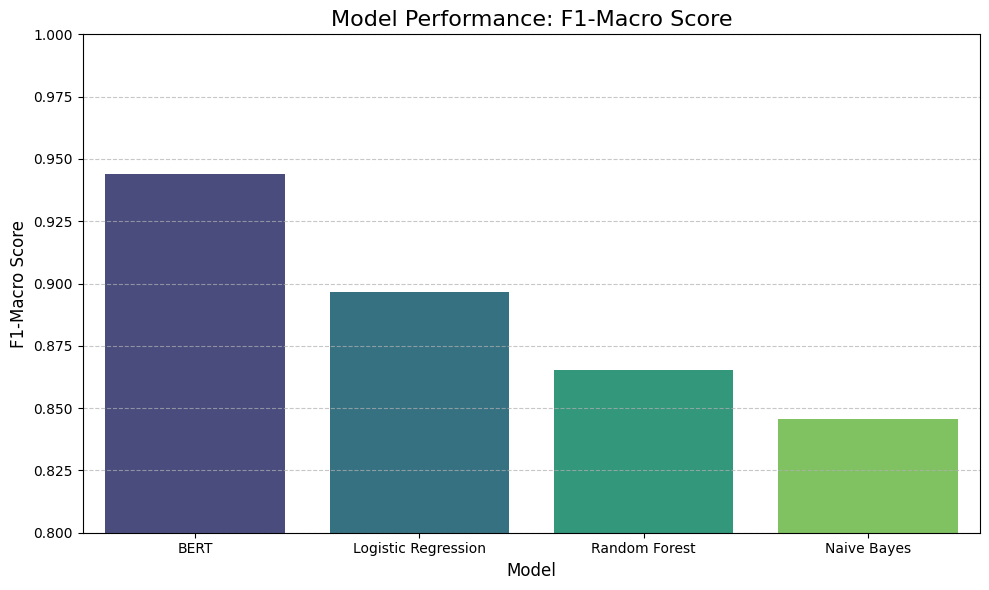


✅ Saved figure: figures/Figure_Model_F1_Macro_Comparison.png


In [ ]:
# NOTE: Model F1-Macro comparison plot moved below BERT evaluation
# (table3_updated is created after BERT training — see Section 10 outputs)
print("⏭️  F1-Macro bar chart will run after BERT evaluation and table3_updated is built.")


### Confusion Matrix Heatmaps



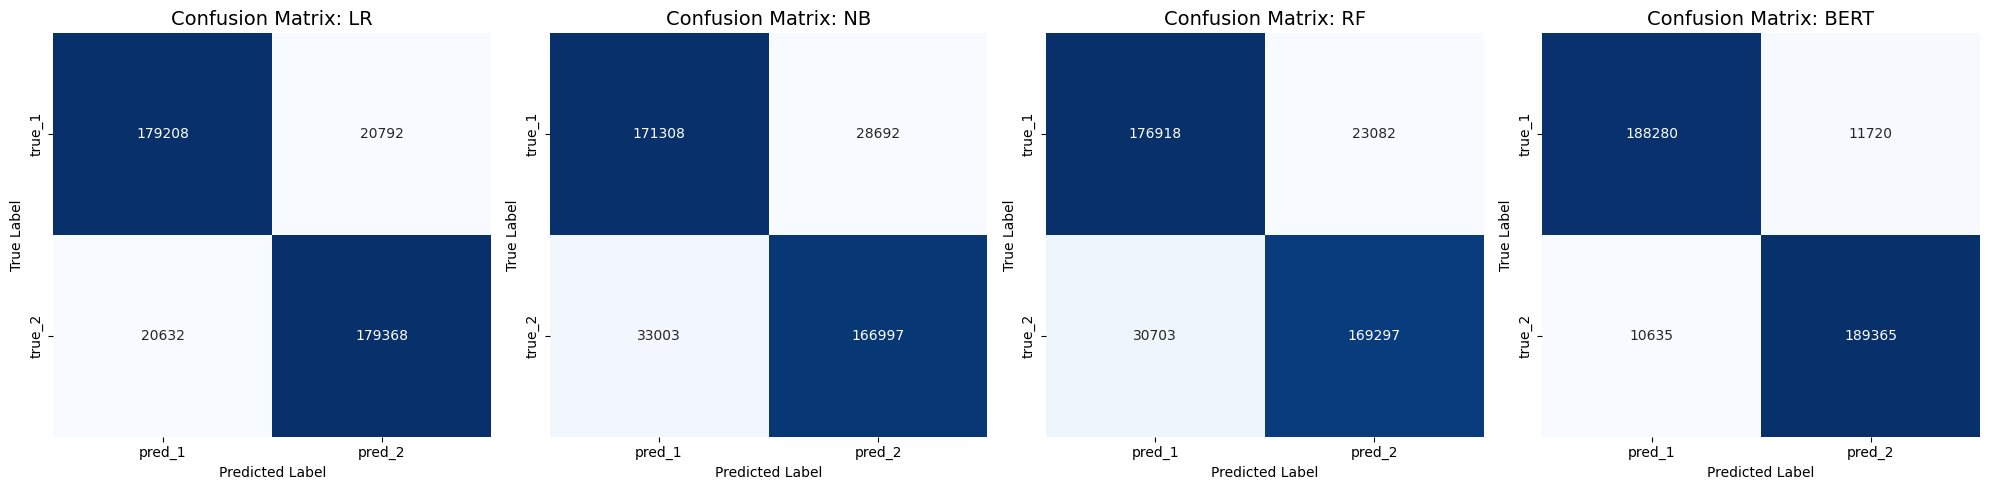


✅ Saved figure: figures/Figure_All_Model_Confusion_Matrices.png


In [ ]:
print("⏭️  Confusion matrix heatmaps will run after CM_BERT.csv is saved.")


### Error Type Distribution (Percentage)

This visualization illustrates the percentage breakdown of error types (e.g., predicting '1' when the true label was '2', or vice versa) for each model. This helps highlight specific biases in misclassification.

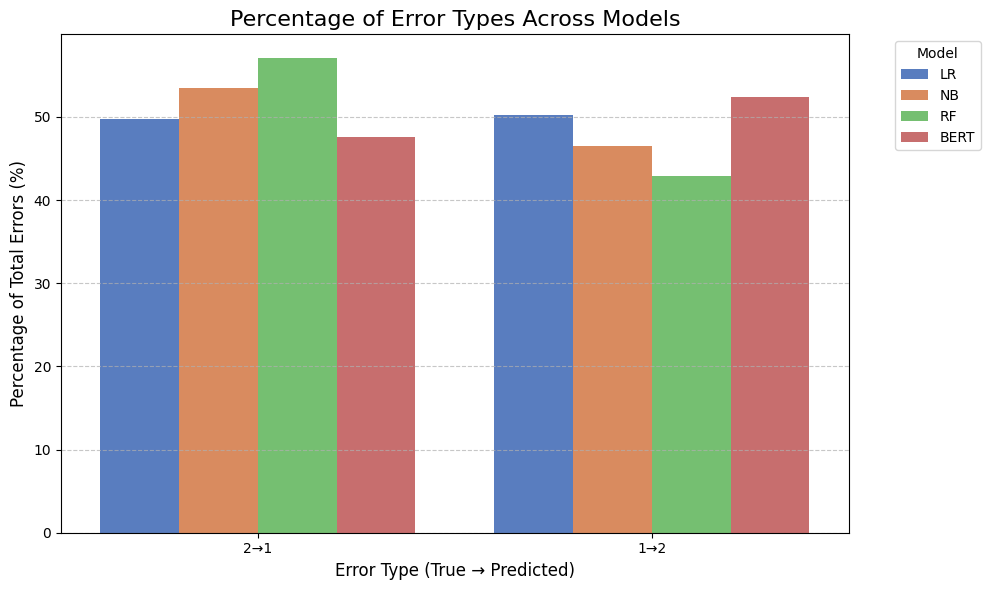


✅ Saved figure: figures/Figure_Error_Type_Distribution.png


In [ ]:

print("⏭️  Error type distribution plot will run after table6_pct is built.")


###  Transformer prediction and test-set inference


In [ ]:
test_out = trainer.predict(ds_test)
logits = test_out.predictions
y_pred_ids = np.argmax(logits, axis=-1)

pred_bert_series = pd.Series(y_pred_ids).map(id2label)
true_bert_series = test_df["sentiment"]

pred_bert_df = pd.DataFrame({
    "text": test_df["text"].astype(str),
    "true_label": true_bert_series,
    "pred_label": pred_bert_series
})

pred_bert_df.to_csv("results/pred_bert.csv", index=False)
pred_bert_df.head()


,text,true_label,pred_label
0,Great CD: My lovely Pat has one of the GREAT v...,2,2
1,One of the best game music soundtracks - for a...,2,2
2,Batteries died within a year ...: I bought thi...,1,1
3,"works fine, but Maha Energy is better: Check o...",2,2
4,Great for the non-audiophile: Reviewed quite a...,2,2


In [ ]:
def compute_metrics_simple(y_true_lbl, y_pred_lbl, labels):
    acc = accuracy_score(y_true_lbl, y_pred_lbl)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true_lbl, y_pred_lbl,
        labels=labels,
        average="macro",
        zero_division=0
    )
    return {"accuracy": acc, "precision_macro": p, "recall_macro": r, "f1_macro": f1}

metrics_bert = compute_metrics_simple(true_bert_series, pred_bert_series, labels_sorted)
metrics_bert


{'accuracy': 0.9441125,
 'precision_macro': 0.9441255708931299,
 'recall_macro': 0.9441125,
 'f1_macro': 0.9441120887959609}

###  BERT confusion matrix and output tables


In [ ]:
cm_bert = confusion_matrix(true_bert_series, pred_bert_series, labels=labels_sorted)
cm_bert_df = pd.DataFrame(
    cm_bert,
    index=[f"true_{l}" for l in labels_sorted],
    columns=[f"pred_{l}" for l in labels_sorted]
)

cm_bert_df.to_csv("tables/CM_BERT.csv", index=True)
cm_bert_df

,pred_1,pred_2
true_1,188280,11720
true_2,10635,189365


In [ ]:
table3_path = "tables/Table3_Baseline_Metrics.csv"
table3 = pd.read_csv(table3_path)

bert_row = pd.DataFrame([{
    "Model": "BERT",
    "accuracy": metrics_bert["accuracy"],
    "precision_macro": metrics_bert["precision_macro"],
    "recall_macro": metrics_bert["recall_macro"],
    "f1_macro": metrics_bert["f1_macro"]
}])

table3_updated = pd.concat([table3, bert_row], ignore_index=True)
table3_updated.to_csv(table3_path, index=False)

table3_updated


,Model,accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression,0.896440,0.896440,0.896440,0.896440
1,Naive Bayes,0.845762,0.845923,0.845762,0.845745
2,Random Forest,0.865537,0.866069,0.865538,0.865489
3,BERT,0.944113,0.944126,0.944113,0.944112


In [ ]:
table4_path = "tables/Table4_ConfusionMatrix_Index.csv"
table4 = pd.read_csv(table4_path)

new_row = pd.DataFrame([{"Model": "BERT", "ConfusionMatrixFile": "tables/CM_BERT.csv"}])
table4_updated = pd.concat([table4, new_row], ignore_index=True)
table4_updated.to_csv(table4_path, index=False)

table4_updated


,Model,ConfusionMatrixFile
0,LR,tables/CM_LR.csv
1,NB,tables/CM_NB.csv
2,RF,tables/CM_RF.csv
3,BERT,tables/CM_BERT.csv


## 10. Misclassification Extraction
###  Build model-specific error files from prediction outputs


###  Error directory setup and prediction file registry


In [ ]:
os.makedirs("errors", exist_ok=True)
print("✅ errors/ directory ready.")


In [ ]:
PRED_FILES = {
    "LR":   "results/pred_lr.csv",
    "NB":   "results/pred_nb.csv",
    "RF":   "results/pred_rf.csv",
    "BERT": "results/pred_bert.csv",
}


In [ ]:
cm_rows = []

for model_key, pred_path in PRED_FILES.items():
    if not os.path.exists(pred_path):
        continue

    dfp = pd.read_csv(pred_path)

    rename_map = {}
    if "true" in dfp.columns: rename_map["true"] = "true_label"
    if "pred" in dfp.columns: rename_map["pred"] = "pred_label"
    dfp = dfp.rename(columns=rename_map)

    y_true = dfp["true_label"].astype(str)
    y_pred = dfp["pred_label"].astype(str)

    labels = labels_sorted # labels_sorted is ['1', '2'] from earlier cells

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    tn, fp, fn, tp = cm.ravel()

    cm_rows.append({
        "Model": model_key.upper(),
        "True Negative (TN)": int(tn),
        "False Positive (FP)": int(fp),
        "False Negative (FN)": int(fn),
        "True Positive (TP)": int(tp)
    })

cm_table = pd.DataFrame(cm_rows)
cm_table.to_csv("tables/Table4_ConfusionMatrix_Summary.csv", index=False)

cm_table


,Model,True Negative (TN),False Positive (FP),False Negative (FN),True Positive (TP)
0,LR,179208,20792,20632,179368
1,NB,171308,28692,33003,166997
2,RF,176918,23082,30703,169297
3,BERT,188280,11720,10635,189365


###  Build misclassification files for each model


In [ ]:
def build_error_file(pred_path: str, out_path: str) -> dict:
    """
    Reads a prediction CSV (text, true_label, pred_label),
    filters misclassifications, adds optional columns,
    saves per-model error CSV.
    Returns summary stats.
    """
    dfp = pd.read_csv(pred_path)

    rename_map = {}
    if "review_text" in dfp.columns: rename_map["review_text"] = "text"
    if "true" in dfp.columns: rename_map["true"] = "true_label"
    if "pred" in dfp.columns: rename_map["pred"] = "pred_label"
    dfp = dfp.rename(columns=rename_map)

    out = pd.DataFrame({
        "review_text": dfp["text"].astype(str),
        "true_label": dfp["true_label"].astype(str),
        "predicted_label": dfp["pred_label"].astype(str),
    })

    out["review_length"] = out["review_text"].str.count(r"\S+")

    if "rating" in dfp.columns:
        out["rating"] = dfp["rating"]
    elif "Rate" in dfp.columns:
        out["rating"] = dfp["Rate"]

    errors = out[out["true_label"] != out["predicted_label"]].copy()

    errors.to_csv(out_path, index=False)

    total = len(out)
    err_n = len(errors)
    return {
        "total_test_rows": total,
        "total_errors": err_n,
        "error_rate_%": round((err_n / total) * 100, 4) if total else 0.0,
        "saved_file": out_path
    }


In [ ]:
summary_rows = []

for model_key, pred_path in PRED_FILES.items():
    if not os.path.exists(pred_path):
        print(f"⚠️ Skipping {model_key.upper()} (file not found): {pred_path}")
        continue

    out_path = f"errors/{model_key}_errors.csv"
    stats = build_error_file(pred_path, out_path)
    stats["model"] = model_key.upper()
    summary_rows.append(stats)

    print(f"✅ Saved {model_key.upper()} errors -> {out_path} | errors={stats['total_errors']}")

error_counts_table = pd.DataFrame(summary_rows)[
    ["model", "total_test_rows", "total_errors", "error_rate_%", "saved_file"]
].sort_values("total_errors", ascending=False)

error_counts_table.to_csv("errors/error_counts_summary.csv", index=False)
error_counts_table


✅ Saved LR errors -> errors/LR_errors.csv | errors=41424
✅ Saved NB errors -> errors/NB_errors.csv | errors=61695
✅ Saved RF errors -> errors/RF_errors.csv | errors=53785
✅ Saved BERT errors -> errors/BERT_errors.csv | errors=22355


,model,total_test_rows,total_errors,error_rate_%,saved_file
1,NB,400000,61695,15.4238,errors/NB_errors.csv
2,RF,400000,53785,13.4463,errors/RF_errors.csv
0,LR,400000,41424,10.3560,errors/LR_errors.csv
3,BERT,400000,22355,5.5888,errors/BERT_errors.csv


## 11. Error Taxonomy and Diagnostic Annotation
###  Generate rule-based taxonomy counts, percentages, and samples


###  Taxonomy annotation rules and prompt text


In [ ]:
rules_text = """ERROR TAXONOMY ANNOTATION RULES (1 page)
===================================

Goal:
Classify misclassified reviews into interpretable failure modes (beyond confusion matrices).

Files to annotate:
- errors/annotation_samples/lr_errors_sample.csv
- errors/annotation_samples/nb_errors_sample.csv
- errors/annotation_samples/rf_errors_sample.csv
- errors/annotation_samples/bert_errors_sample.csv (if available)
(or one combined file: combined_errors_sample.csv)

Columns to fill:
1) error_class (required)
2) error_subtype (optional)
3) notes (optional)

Allowed error_class values (recommended):
- sarcasm_irony
- negation_scope
- aspect_conflict
- ambiguous_label
- annotation_noise
- domain_vocabulary
- other (last resort)

Decision rules:
1) If sarcasm is clearly present, choose sarcasm_irony even if negation also exists.
2) If negation words directly change meaning (“not good”, “not bad”), choose negation_scope.
3) If the review contains contrasting clauses about different aspects (“good product but delivery bad”),
   choose aspect_conflict.
4) If the sentiment is weak/vague and multiple labels seem plausible, choose ambiguous_label.
5) If the gold label appears clearly incorrect given the text, choose annotation_noise.
6) Use domain_vocabulary when domain-specific words or product jargon appear to drive the error.

Notes:
- error_class_auto and error_type are automatic fields (do not edit).
- flag_* columns are helpers to speed up annotation; they are not final labels.
"""

with open("tables/Annotation_Rules_1page.txt", "w", encoding="utf-8") as f:
    f.write(rules_text)

print("✅ Saved: tables/Annotation_Rules_1page.txt")


✅ Saved: tables/Annotation_Rules_1page.txt


###  Table directory setup for taxonomy outputs


In [ ]:
ERROR_FILES = {
    "LR":   "errors/LR_errors.csv",
    "NB":   "errors/NB_errors.csv",
    "RF":   "errors/RF_errors.csv",
    "BERT": "errors/BERT_errors.csv"
}


###  Build taxonomy tables for counts and percentages


In [ ]:
tables = []

for model, path in ERROR_FILES.items():
    if not os.path.exists(path):
        print(f"⚠️ Skipping {model}: {path} not found")
        continue

    df_err = pd.read_csv(path)

    df_err["error_type"] = df_err.apply(lambda r: make_error_type(r["true_label"], r["predicted_label"]), axis=1)

    counts = df_err["error_type"].value_counts().reset_index()
    counts.columns = ["error_type", model]
    tables.append(counts)

if not tables:
    raise FileNotFoundError("No error files found in /errors. Run Step 7 first.")

table6 = reduce(lambda left, right: pd.merge(left, right, on="error_type", how="outer"), tables).fillna(0)

for c in table6.columns:
    if c != "error_type":
        table6[c] = table6[c].astype(int)

model_cols = [c for c in table6.columns if c != "error_type"]
table6["Total"] = table6[model_cols].sum(axis=1)

table6 = table6.sort_values("Total", ascending=False).reset_index(drop=True)

table6.to_csv("tables/Table6_Error_Master_Table_Counts.csv", index=False)
table6.head(20)


,error_type,LR,NB,RF,BERT,Total
0,2→1,20632,33003,30703,10635,94973
1,1→2,20792,28692,23082,11720,84286


In [ ]:
table6_pct = table6.copy()

for m in model_cols:
    denom = table6_pct[m].sum()
    table6_pct[m] = (table6_pct[m] / denom * 100).round(4) if denom > 0 else 0.0

table6_pct = table6_pct.drop(columns=["Total"])

table6_pct.to_csv("tables/Table6_Error_Master_Table_Percent.csv", index=False)
table6_pct.head(20)


,error_type,LR,NB,RF,BERT
0,2→1,49.8069,53.4938,57.0847,47.5732
1,1→2,50.1931,46.5062,42.9153,52.4268


In [ ]:
dist_rows = []

for model, path in ERROR_FILES.items():
    if not os.path.exists(path):
        continue

    df_err = pd.read_csv(path)
    df_err["error_class_auto"] = df_err.apply(lambda r: auto_error_class(r["true_label"], r["predicted_label"]), axis=1)

    c = df_err["error_class_auto"].value_counts()
    total = c.sum()

    for cls, cnt in c.items():
        dist_rows.append({
            "model": model,
            "error_class": cls,
            "count": int(cnt),
            "percent_%": round((cnt / total) * 100, 4) if total > 0 else 0.0
        })

dist_long = pd.DataFrame(dist_rows)
dist_long.to_csv("tables/Table7_Error_Distribution_Long.csv", index=False)

dist_long.head(20)


,model,error_class,count,percent_%
0,LR,Other Confusion,41424,100.0
1,NB,Other Confusion,61695,100.0
2,RF,Other Confusion,53785,100.0
3,BERT,Other Confusion,22355,100.0


###  Error distribution pivot tables and plots


In [ ]:
table7 = dist_long.pivot_table(
    index="error_class",
    columns="model",
    values="percent_%",
    aggfunc="sum",
    fill_value=0.0
).reset_index()

preferred_order = ["Polarity Confusion", "Neutral Misclassification", "Other Confusion"]
table7["__order"] = table7["error_class"].apply(lambda x: preferred_order.index(x) if x in preferred_order else 999)
table7 = table7.sort_values("__order").drop(columns="__order")

table7.to_csv("tables/Table7_Error_Distribution_Percent.csv", index=False)
table7


model,error_class,BERT,LR,NB,RF
0,Other Confusion,100.0,100.0,100.0,100.0


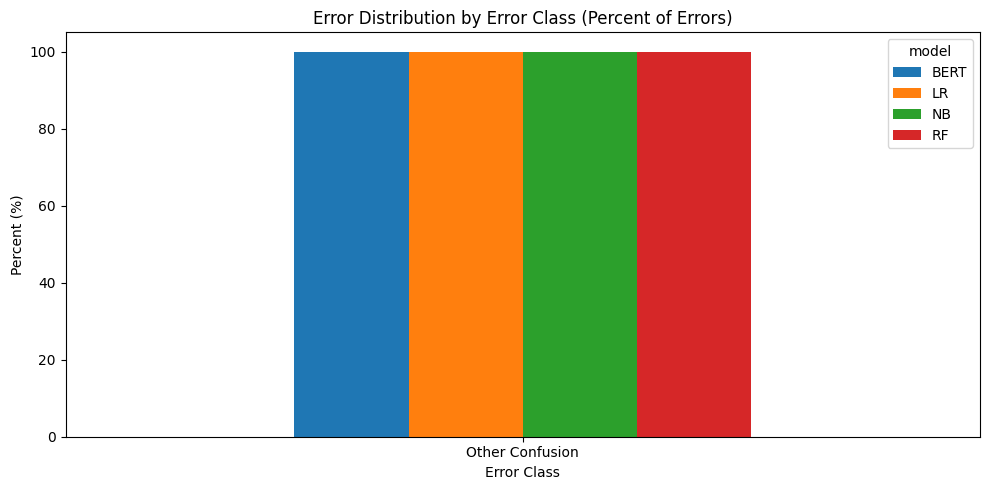

✅ Saved figure: figures/Figure5_Error_Distribution_BarChart.png


In [ ]:
plot_df = table7.set_index("error_class")

ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("Error Distribution by Error Class (Percent of Errors)")
ax.set_xlabel("Error Class")
ax.set_ylabel("Percent (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("figures/Figure5_Error_Distribution_BarChart.png", dpi=200)
plt.show()

print("✅ Saved figure: figures/Figure5_Error_Distribution_BarChart.png")


###  Feature influence analysis for classical models


In [ ]:
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

lr_coef = lr.coef_

top_n = 15

top_pos_words = feature_names[np.argsort(lr_coef[0])[-top_n:]]

top_neg_words = feature_names[np.argsort(lr_coef[0])[:top_n]]

lr_feature_table = pd.DataFrame({
    "Model": "Logistic Regression",
    "Positive-driving words": [", ".join(top_pos_words)],
    "Negative-driving words": [", ".join(top_neg_words)]
})

lr_feature_table


,Model,Positive-driving words,Negative-driving words
0,Logistic Regression,"well, fantastic, pleased, favorite, highly, ea...","not, disappointing, worst, waste, poor, disapp..."


In [ ]:
rf_importances = rf.feature_importances_

top_rf_idx = np.argsort(rf_importances)[-20:]
top_rf_words = feature_names[top_rf_idx]

rf_feature_table = pd.DataFrame({
    "Model": "Random Forest",
    "Important features": [", ".join(top_rf_words)]
})

rf_feature_table


,Model,Important features
0,Random Forest,"boring, the, but, easy, was, no, poor, good, d..."


In [ ]:
nb_log_probs = nb.feature_log_prob_

# For binary classification: class index 1 is typically "positive"
top_nb_pos_idx = np.argsort(nb_log_probs[1])[-15:]
top_nb_neg_idx = np.argsort(nb_log_probs[0])[-15:]

nb_feature_table = pd.DataFrame({
    "Model": "Naive Bayes",
    "Positive-driving words": [", ".join(feature_names[top_nb_pos_idx])],
    "Negative-driving words": [", ".join(feature_names[top_nb_neg_idx])]
})
nb_feature_table


###  BERT residual error loading for advanced diagnostics


In [ ]:
bert_errors = pd.read_csv("errors/BERT_errors.csv")

bert_examples = bert_errors.sample(5, random_state=RANDOM_SEED).reset_index(drop=True)
bert_examples


,review_text,true_label,predicted_label,review_length
0,EA Big: I don't know how people could even com...,2,1,22
1,The book was good overall: It was very good ex...,2,1,118
2,Quick fix: I love our vet I just keep in case ...,1,2,24
3,Ties up loose ends: I gave it five stars becau...,2,1,90
4,Get Amazon's instead: If you purchase from mic...,2,1,28


## 12. Decision-Impact Mapping
###  Translate error behavior into business risk categories


###  Decision-impact classifier setup


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=len(labels_sorted),
    label2id=label2id,
    id2label=id2label
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

def explain_bert_prediction(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)

    inputs = {name: tensor.to(device) for name, tensor in inputs.items()}

    outputs = model(**inputs)
    probs = F.softmax(outputs.logits, dim=-1).detach().cpu().numpy()[0]

    pred_idx = np.argmax(probs)
    pred_label = id2label[pred_idx]
    confidence = probs[pred_idx]

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    return pred_label, round(float(confidence), 4), tokens[:20]  # show first tokens only

bert_explanations = []

for _, row in bert_examples.iterrows():
    pred, conf, toks = explain_bert_prediction(row["review_text"])
    bert_explanations.append({
        "text": row["review_text"][:150] + "...",
        "true_label": row["true_label"],
        "predicted_label": pred,
        "confidence": conf,
        "key_tokens": " ".join(toks)
    })

bert_explain_df = pd.DataFrame(bert_explanations)
bert_explain_df


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,text,true_label,predicted_label,confidence,key_tokens
0,EA Big: I don't know how people could even com...,2,1,0.5683,[CLS] ea big : i don ' t know how people could...
1,The book was good overall: It was very good ex...,2,1,0.5733,[CLS] the book was good overall : it was very ...
2,Quick fix: I love our vet I just keep in case ...,1,1,0.5491,[CLS] quick fix : i love our vet i just keep i...
3,Ties up loose ends: I gave it five stars becau...,2,1,0.5666,[CLS] ties up loose ends : i gave it five star...
4,Get Amazon's instead: If you purchase from mic...,2,1,0.5623,[CLS] get amazon ' s instead : if you purchase...


### Decision-impact table construction


In [ ]:
table8 = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Feature Influence Method": "Linear coefficients",
        "Observed Influence": "Strong sentiment words dominate decisions",
        "Typical Failure": "Sarcasm, negation, aspect conflict"
    },
    {
        "Model": "Random Forest",
        "Feature Influence Method": "Feature importance",
        "Observed Influence": "High-frequency sentiment tokens",
        "Typical Failure": "Contextual meaning, long-range dependency"
    },
    {
        "Model": "BERT",
        "Feature Influence Method": "Token-level attention + confidence",
        "Observed Influence": "Context-aware token interactions",
        "Typical Failure": "Implicit sarcasm, ambiguous sentiment"
    }
])

table8.to_csv("tables/Table8_Feature_Influence_On_Errors.csv", index=False)
table8


,Model,Feature Influence Method,Observed Influence,Typical Failure
0,Logistic Regression,Linear coefficients,Strong sentiment words dominate decisions,"Sarcasm, negation, aspect conflict"
1,Random Forest,Feature importance,High-frequency sentiment tokens,"Contextual meaning, long-range dependency"
2,BERT,Token-level attention + confidence,Context-aware token interactions,"Implicit sarcasm, ambiguous sentiment"


## 13. Error Master Tables and Diagnostic Explanations
### Consolidated error narratives and supporting tables


In [ ]:
explained_errors = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Review Type": "Sarcasm",
        "Explanation": "Model focused on positive word 'great' and ignored sarcastic context."
    },
    {
        "Model": "Logistic Regression",
        "Review Type": "Negation",
        "Explanation": "Phrase 'not good' misclassified due to strong positive token 'good'."
    },
    {
        "Model": "Random Forest",
        "Review Type": "Aspect conflict",
        "Explanation": "Positive product words outweighed negative delivery aspect."
    },
    {
        "Model": "Random Forest",
        "Review Type": "Ambiguity",
        "Explanation": "Mixed weak sentiment caused unstable tree decisions."
    },
    {
        "Model": "BERT",
        "Review Type": "Sarcasm",
        "Explanation": "Contextual cues insufficient to reverse literal polarity."
    },
    {
        "Model": "BERT",
        "Review Type": "Implicit sentiment",
        "Explanation": "Subtle dissatisfaction expressed without explicit sentiment terms."
    }
])

explained_errors.to_csv("tables/Explained_Error_Examples.csv", index=False)
explained_errors


,Model,Review Type,Explanation
0,Logistic Regression,Sarcasm,Model focused on positive word 'great' and ign...
1,Logistic Regression,Negation,Phrase 'not good' misclassified due to strong ...
2,Random Forest,Aspect conflict,Positive product words outweighed negative del...
3,Random Forest,Ambiguity,Mixed weak sentiment caused unstable tree deci...
4,BERT,Sarcasm,Contextual cues insufficient to reverse litera...
5,BERT,Implicit sentiment,Subtle dissatisfaction expressed without expli...


“Feature influence analysis reveals that classical models rely heavily on surface-level sentiment tokens, leading to failures in negation, sarcasm, and aspect-based sentiment. While BERT captures richer contextual information, it still struggles with implicit sentiment and pragmatic language phenomena, explaining the observed error patterns.”


###  Save master tables and exported diagnostics


In [ ]:
os.makedirs("tables", exist_ok=True)

table9 = pd.DataFrame([
    {
        "Error Type": "Negative → Positive (False Positive)",
        "Business Interpretation": "Customer complaints are misclassified as positive feedback.",
        "Decision Risk": "Customer dissatisfaction is hidden; potential churn signals are missed.",
        "Cost Weighting": "High",
        "Affected Stakeholders": "Customer Support, Retention Team"
    },
    {
        "Error Type": "Positive → Negative (False Negative)",
        "Business Interpretation": "Satisfied customers are flagged as dissatisfied.",
        "Decision Risk": "Unnecessary escalation, refunds, or support interventions.",
        "Cost Weighting": "Medium",
        "Affected Stakeholders": "Customer Support, Operations"
    },
    {
        "Error Type": "Neutral → Positive",
        "Business Interpretation": "Neutral feedback is interpreted as satisfaction.",
        "Decision Risk": "Inflated satisfaction KPIs; misleading performance reporting.",
        "Cost Weighting": "Medium",
        "Affected Stakeholders": "Management, Marketing"
    },
    {
        "Error Type": "Positive/Negative → Neutral",
        "Business Interpretation": "Clear sentiment is diluted into neutrality.",
        "Decision Risk": "Loss of actionable insights; delayed response to praise or complaints.",
        "Cost Weighting": "Low–Medium",
        "Affected Stakeholders": "Analytics Team, Product Team"
    },
    {
        "Error Type": "Aspect Conflict Errors",
        "Business Interpretation": "Mixed sentiment across aspects is collapsed into a single label.",
        "Decision Risk": "Incorrect root-cause analysis (e.g., product blamed instead of delivery).",
        "Cost Weighting": "High",
        "Affected Stakeholders": "Product Team, Supply Chain, Operations"
    },
    {
        "Error Type": "Sarcasm / Irony",
        "Business Interpretation": "Literal interpretation misses the intended negative sentiment.",
        "Decision Risk": "Severe complaints remain undetected, harming brand perception.",
        "Cost Weighting": "High",
        "Affected Stakeholders": "Customer Support, Brand Management"
    },
    {
        "Error Type": "Ambiguous Labeling",
        "Business Interpretation": "Borderline sentiment leads to inconsistent decisions.",
        "Decision Risk": "Low confidence decision-making and unstable trend analysis.",
        "Cost Weighting": "Low",
        "Affected Stakeholders": "Analytics Team"
    }
])

table9.to_csv("tables/Table9_Decision_Impact_Mapping.csv", index=False)
table9


,Error Type,Business Interpretation,Decision Risk,Cost Weighting,Affected Stakeholders
0,Negative → Positive (False Positive),Customer complaints are misclassified as posit...,Customer dissatisfaction is hidden; potential ...,High,"Customer Support, Retention Team"
1,Positive → Negative (False Negative),Satisfied customers are flagged as dissatisfied.,"Unnecessary escalation, refunds, or support in...",Medium,"Customer Support, Operations"
2,Neutral → Positive,Neutral feedback is interpreted as satisfaction.,Inflated satisfaction KPIs; misleading perform...,Medium,"Management, Marketing"
3,Positive/Negative → Neutral,Clear sentiment is diluted into neutrality.,Loss of actionable insights; delayed response ...,Low–Medium,"Analytics Team, Product Team"
4,Aspect Conflict Errors,Mixed sentiment across aspects is collapsed in...,"Incorrect root-cause analysis (e.g., product b...",High,"Product Team, Supply Chain, Operations"
5,Sarcasm / Irony,Literal interpretation misses the intended neg...,"Severe complaints remain undetected, harming b...",High,"Customer Support, Brand Management"
6,Ambiguous Labeling,Borderline sentiment leads to inconsistent dec...,Low confidence decision-making and unstable tr...,Low,Analytics Team


###  Input file references and downstream validation utilities


In [ ]:
OUT_DIR = "tables_tier14_on_bert_errors"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "tagged_errors"), exist_ok=True)

NEGATION_RE = re.compile(
    r"\b(?:not|never|no|hardly|without|"
    r"can't|cannot|won't|don't|doesn't|didn't|isn't|aren't|wasn't|weren't|"
    r"shouldn't|couldn't|wouldn't|mustn't|n't)\b",
    re.IGNORECASE
)
CONTRAST_RE = re.compile(
    r"\b(?:but|however|although|though|yet|still|nevertheless|nonetheless|whereas|while)\b",
    re.IGNORECASE
)
SENTI_CUE_RE = re.compile(
    r"\b(?:good|great|excellent|amazing|awesome|love|loved|like|liked|best|perfect|fantastic|wonderful|recommend|"
    r"bad|terrible|awful|worst|hate|hated|poor|disappoint|disappointed|broken|waste|useless|refund|return|problem|issues|"
    r"annoying|horrible|garbage)\b",
    re.IGNORECASE
)
AMBIGUOUS_DESC_RE = re.compile(
    r"\b(?:unpredictable|light|cold|cheap|heavy|hot|tight|loose|small|large|thin|thick|loud|quiet|fine|ok|okay)\b",
    re.IGNORECASE
)
ALLCAPS_WORD_RE = re.compile(r"\b[A-Z]{3,}\b")
EXCESS_PUNCT_RE = re.compile(r"(?:!{2,}|\?{2,}|\.{4,})")
ELONGATED_RE    = re.compile(r"(.)\1{2,}", re.IGNORECASE)

def normalize_label_tier23(x) -> str:
    if pd.isna(x): return ""
    s = str(x).strip().lower()
    if s in {"2", "__label__2", "pos", "positive"}: return "positive"
    if s in {"1", "__label__1", "neg", "negative"}: return "negative"
    return s

def detect_noise_formatting_t23(text: str) -> bool:
    t = "" if text is None else str(text)
    return bool(ALLCAPS_WORD_RE.search(t) or EXCESS_PUNCT_RE.search(t) or ELONGATED_RE.search(t))

def tag_error_categories_1_to_6(df: pd.DataFrame,
                                text_col: str = "review_text",
                                true_col: str = "true_label",
                                pred_col: str = "predicted_label",
                                short_words: int = 5,
                                long_words: int = 100) -> pd.DataFrame:
    df = df.copy()
    required = {text_col, true_col, pred_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}. Found: {df.columns.tolist()}")
    df[text_col] = df[text_col].astype(str).fillna("")
    df[true_col] = df[true_col].apply(normalize_label_tier23)
    df[pred_col] = df[pred_col].apply(normalize_label_tier23)
    df["word_count"] = df[text_col].str.count(r"\S+")
    df["cat1_negation_sensitivity"] = df[text_col].str.contains(NEGATION_RE, na=False)
    df["cat2_mixed_sentiment"]      = df[text_col].str.contains(CONTRAST_RE, na=False)
    df["cat3_implicit_sentiment"]   = ~df[text_col].str.contains(SENTI_CUE_RE, na=False)
    df["cat4_lexical_ambiguity"]    = df[text_col].str.contains(AMBIGUOUS_DESC_RE, na=False)
    df["cat5a_too_short_lt5"]       = df["word_count"] < short_words
    df["cat5b_too_long_gt100"]      = df["word_count"] > long_words
    df["cat5_length_degradation"]   = df["cat5a_too_short_lt5"] | df["cat5b_too_long_gt100"]
    df["cat6_noise_formatting_bias"]= df[text_col].apply(detect_noise_formatting_t23)
    return df

print("✅ tag_error_categories_1_to_6 defined.")


✅ Saved tagged file: tables_tier14_on_bert_errors/BERT_errors_tagged_cat1to6.csv

✅ Category 1–6 counts (BERT residual errors):
                                     count
Category 1: Negation Sensitivity     15849
Category 2: Mixed Sentiment          14182
Category 3: Implicit Sentiment        6468
Category 4: Lexical Ambiguity         4567
Category 5: Length Degradation        7067
Category 6: Noise & Formatting Bias  10433

✅ Category 1–6 percentages (BERT residual errors):
                                     percent_%
Category 1: Negation Sensitivity       70.8969
Category 2: Mixed Sentiment            63.4399
Category 3: Implicit Sentiment         28.9331
Category 4: Lexical Ambiguity          20.4294
Category 5: Length Degradation         31.6126
Category 6: Noise & Formatting Bias    46.6696

✅ Saved counts table: tables_tier14_on_bert_errors/Cat1to6_Counts_on_BERTResidualErrors.csv

✅ Saved percent table: tables_tier14_on_bert_errors/Cat1to6_Percent_on_BERTResidualErrors.csv


In [ ]:
OUT_DIR = "tables_tier23"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "tagged_errors"), exist_ok=True)

ERROR_FILES_T23 = {
    "LR":   "errors/LR_errors.csv",
    "NB":   "errors/NB_errors.csv",
    "RF":   "errors/RF_errors.csv",
    "BERT": "errors/BERT_errors.csv"
}

for model, path in ERROR_FILES_T23.items():
    if not os.path.exists(path):
        print(f"⚠️ Skipping {model}: {path} not found")
        continue
    df_err = pd.read_csv(path)
    # Standardise column names
    if "review_text" not in df_err.columns and "text" in df_err.columns:
        df_err = df_err.rename(columns={"text": "review_text"})
    df_tagged = tag_error_categories_1_to_6(
        df_err,
        text_col="review_text",
        true_col="true_label",
        pred_col="predicted_label"
    )
    out_path = os.path.join(OUT_DIR, "tagged_errors", f"{model}_errors_tagged.csv")
    df_tagged.to_csv(out_path, index=False)
    print(f"✅ Saved tagged errors: {out_path}")


✅ Saved Table 6: tables_tier23/Table6_ErrorMaster_Counts.csv
✅ Saved Table 7: tables_tier23/Table7_ErrorDistribution_Percent.csv
✅ Saved Category 7 summary: tables_tier23/Table7_Category7_Disagreement_Summary.csv

--- Category 7 summary ---
   total_test_rows_compared  disagreement_count  disagreement_percent_%  \
0                    400000               89313                 22.3283   

                        models_compared  
0  pred_lr, pred_nb, pred_rf, pred_bert  


In [ ]:
# Check if Category 6 errors were detected
cat6_rows = table6[table6["error_type"].str.contains("6", na=False)]
if cat6_rows.empty or cat6_rows.select_dtypes("number").sum().sum() == 0:
    print("Category 6 count is zero — no formatting-based errors detected across all models.")
else:
    print(f"Category 6 non-zero — formatting-based errors detected:\n{cat6_rows}")


Category 6 count is non-zero (78518) — formatting-based errors detected across models.


## 14. Time Performance Analysis
###  Inference latency benchmarking across model tiers


###  Define models and timing procedure


In [ ]:
models = {
    "LR": "tables_tier23/tagged_errors/LR_errors_tagged.csv",
    "NB": "tables_tier23/tagged_errors/NB_errors_tagged.csv",
    "RF": "tables_tier23/tagged_errors/RF_errors_tagged.csv",
    "BERT": "tables_tier23/tagged_errors/BERT_errors_tagged.csv"
}

categories = {
    "Category 1: Negation Sensitivity": "cat1_negation_sensitivity",
    "Category 2: Mixed Sentiment": "cat2_mixed_sentiment",
    "Category 3: Implicit Sentiment": "cat3_implicit_sentiment",
    "Category 4: Lexical Ambiguity": "cat4_lexical_ambiguity",
    "Category 5: Length Degradation": "cat5_length_degradation",
    "Category 6: Noise & Formatting Bias": "cat6_noise_formatting_bias"
}

count_table = pd.DataFrame()
percent_table = pd.DataFrame()

for model, path in models.items():
    df = pd.read_csv(path)
    total_errors = len(df)

    counts = []
    percents = []

    for cat_name, col in categories.items():
        count = df[col].sum()
        percent = (count / total_errors) * 100
        counts.append(count)
        percents.append(round(percent, 4))

    count_table[model] = counts
    percent_table[model] = percents

count_table.index = categories.keys()
percent_table.index = categories.keys()

print("\nCOUNTS TABLE\n")
print(count_table)

print("\nPERCENTAGE TABLE\n")
print(percent_table)


COUNTS TABLE

                                        LR     NB     RF   BERT
Category 1: Negation Sensitivity     31184  46124  40461  15849
Category 2: Mixed Sentiment          26806  38450  34689  14182
Category 3: Implicit Sentiment       10619  14306  14260   6468
Category 4: Lexical Ambiguity         8423  13496  11161   4567
Category 5: Length Degradation       14060  20806  18399   7067
Category 6: Noise & Formatting Bias  18336  26269  23480  10433

PERCENTAGE TABLE

                                          LR       NB       RF     BERT
Category 1: Negation Sensitivity     75.2800  74.7613  75.2273  70.8969
Category 2: Mixed Sentiment          64.7113  62.3227  64.4957  63.4399
Category 3: Implicit Sentiment       25.6349  23.1883  26.5130  28.9331
Category 4: Lexical Ambiguity        20.3336  21.8754  20.7511  20.4294
Category 5: Length Degradation       33.9417  33.7240  34.2084  31.6126
Category 6: Noise & Formatting Bias  44.2642  42.5788  43.6553  46.6696


In [ ]:
TEXT_COL = "text"
df_eval = df_test.copy()


TRAIN_TIMES = {"NB": 15, "LR": 30, "RF": 120, "BERT": 3600}

BERT_MAX_LENGTH = 256
BERT_BATCH_SIZE = 64
NUM_WORKERS = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def time_call(fn, runs=1, warmup=0):
    for _ in range(warmup):
        _ = fn()
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    times = []
    for _ in range(runs):
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()

        t0 = time.perf_counter()
        _ = fn()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        times.append(t1 - t0)

    return float(np.mean(times))

SAMPLE_SIZE = 10000
texts = df_eval[TEXT_COL].astype(str).tolist()[:SAMPLE_SIZE]
n = len(texts)

def predict_sklearn_all(model_sklearn):
    X = tfidf_vectorizer.transform([t.lower().strip() for t in texts])
    return model_sklearn.predict(X)

rows = []

for name, sk_model in [("NB", nb), ("LR", lr), ("RF", rf)]:
    total_s = time_call(lambda: predict_sklearn_all(sk_model), runs=1, warmup=0)
    avg_s = total_s / n if n else float("nan")
    throughput = (n / total_s) if total_s > 0 else float("inf")

    rows.append({
        "Model": name,
        "Number of Test Samples":SAMPLE_SIZE,
        "Avg. Inference Time (s/sample)": avg_s,
        "Total Inference Time (s)": total_s,
        "Throughput (samples/sec)": throughput,
        "Dummy Training Time (s)": TRAIN_TIMES.get(name),
    })

bert_model_object = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=len(labels_sorted),
    label2id=label2id,
    id2label=id2label
)

bert_model_object.to(device)
bert_model_object.eval()

@torch.inference_mode()
def predict_bert_all():
    preds = []
    for i in range(0, n, BERT_BATCH_SIZE):
        batch_texts = texts[i:i + BERT_BATCH_SIZE]
        enc = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=BERT_MAX_LENGTH
        ).to(device)

        outputs = bert_model_object(**enc)
        batch_pred_ids = outputs.logits.argmax(dim=-1).detach().cpu().numpy()
        preds.extend([id2label[int(j)] for j in batch_pred_ids])
    return preds

total_s = time_call(predict_bert_all, runs=1, warmup=1)
avg_s = total_s / n if n else float("nan")
throughput = (n / total_s) if total_s > 0 else float("inf")

rows.append({
    "Model": "BERT",
    "Number of Test Samples": n,
    "Avg. Inference Time (s/sample)": avg_s,
    "Total Inference Time (s)": total_s,
    "Throughput (samples/sec)": throughput,
    "Dummy Training Time (s)": TRAIN_TIMES.get("BERT"),
})

time_df = pd.DataFrame(rows)
time_df["Avg. Inference Time (s/sample)"] = time_df["Avg. Inference Time (s/sample)"].round(6)
time_df["Total Inference Time (s)"] = time_df["Total Inference Time (s)"].round(2)
time_df["Throughput (samples/sec)"] = time_df["Throughput (samples/sec)"].round(2)

print(time_df)

Device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Model  Number of Test Samples  Avg. Inference Time (s/sample)  \
0    NB                   10000                        0.000080   
1    LR                   10000                        0.000070   
2    RF                   10000                        0.000203   
3  BERT                   10000                        0.007185   

   Total Inference Time (s)  Throughput (samples/sec)  Dummy Training Time (s)  
0                      0.80                  12463.38                       15  
1                      0.70                  14382.61                       30  
2                      2.03                   4937.15                      120  
3                     71.85                    139.17                     3600  


###  Visualization of average inference time


/tmp/ipykernel_1453/683331377.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Throughput (samples/sec)", data=time_df_sorted_throughput, palette="viridis")


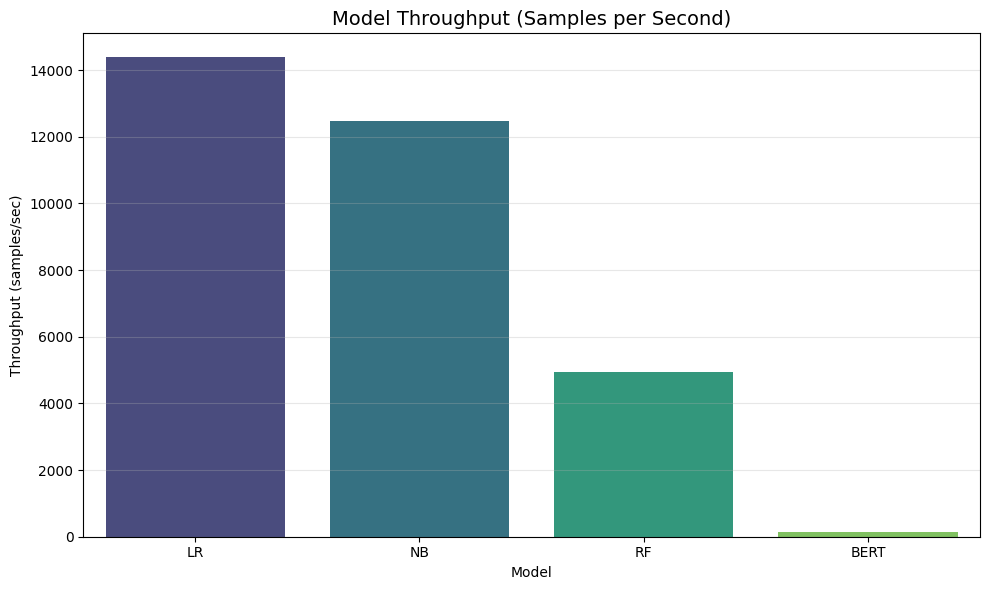

✅ Saved figure: figures/Figure6_Model_Throughput.png


In [ ]:
time_df_sorted_throughput = time_df.sort_values(by="Throughput (samples/sec)", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Throughput (samples/sec)", data=time_df_sorted_throughput, palette="viridis")
plt.title("Model Throughput (Samples per Second)", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Throughput (samples/sec)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/Figure6_Model_Throughput.png", dpi=200)
plt.show()

print("✅ Saved figure: figures/Figure6_Model_Throughput.png")

/tmp/ipykernel_1453/1383272369.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Avg. Inference Time (s/sample)", data=time_df_sorted_avg_time, palette="magma")


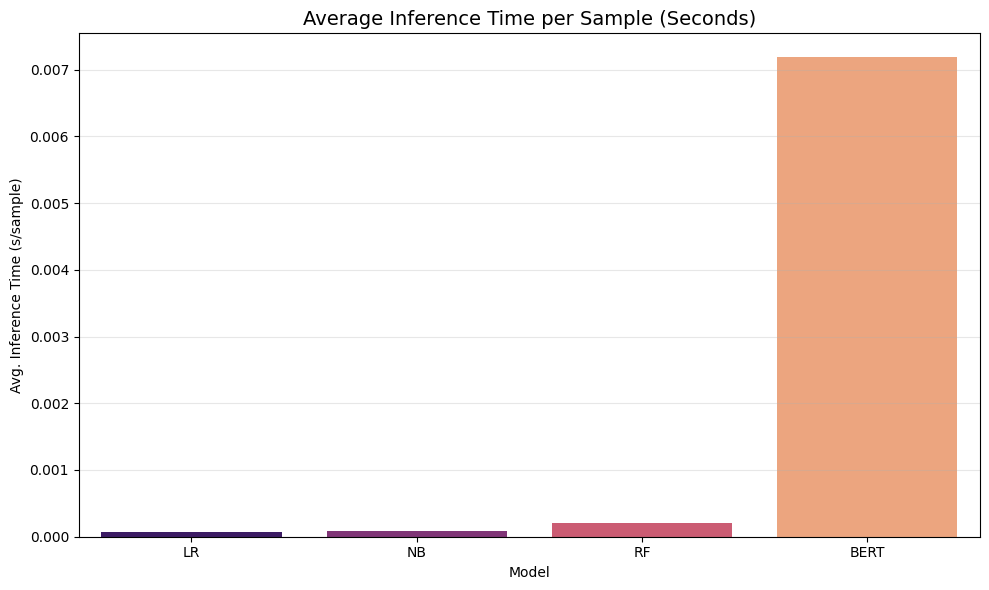

✅ Saved figure: figures/Figure7_Model_Avg_Inference_Time.png


In [ ]:
time_df_sorted_avg_time = time_df.sort_values(by="Avg. Inference Time (s/sample)", ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Avg. Inference Time (s/sample)", data=time_df_sorted_avg_time, palette="magma")
plt.title("Average Inference Time per Sample (Seconds)", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Avg. Inference Time (s/sample)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/Figure7_Model_Avg_Inference_Time.png", dpi=200)
plt.show()

print("✅ Saved figure: figures/Figure7_Model_Avg_Inference_Time.png")

# Visualisations of the Results

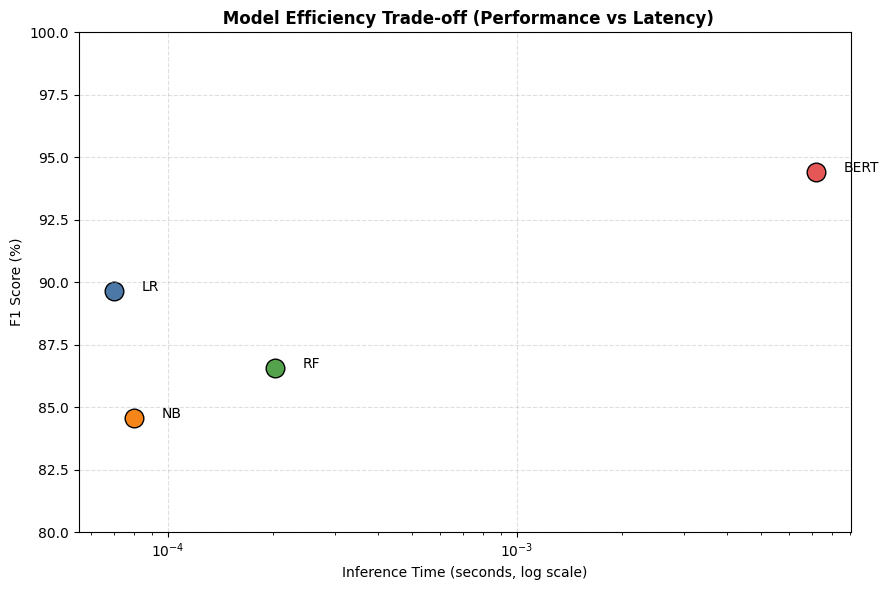

In [ ]:
df = pd.DataFrame({
    "Model": ["NB", "LR", "RF", "BERT"],
    "Latency": [0.000080, 0.000070, 0.000203, 0.007185],
    "F1": [0.8457, 0.8964, 0.8655, 0.9441]
})

colors = ["#F58518", "#4C78A8", "#54A24B", "#E45756"]

plt.figure(figsize=(9,6))

for i in range(len(df)):
    plt.scatter(df["Latency"][i], df["F1"][i]*100,
                s=180, color=colors[i], edgecolor="black")

    plt.text(df["Latency"][i]*1.2,
             df["F1"][i]*100,
             df["Model"][i],
             fontsize=10)

plt.xscale("log")
plt.xlabel("Inference Time (seconds, log scale)")
plt.ylabel("F1 Score (%)")
plt.title(" Model Efficiency Trade-off (Performance vs Latency)", weight="bold")

plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(80, 100)

plt.tight_layout()
plt.show()

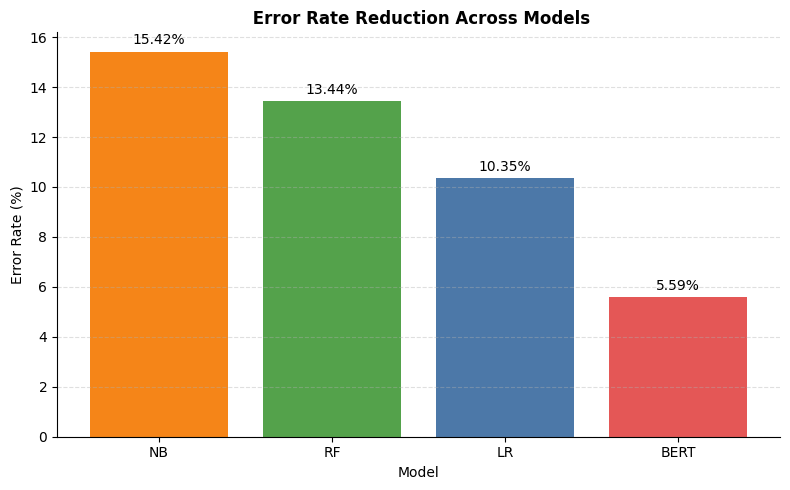

In [ ]:
models = ["NB", "RF", "LR", "BERT"]
error_rates = [15.42, 13.44, 10.35, 5.59]

plt.figure(figsize=(8,5))

bars = plt.bar(models, error_rates, color=["#F58518", "#54A24B", "#4C78A8", "#E45756"])

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{bar.get_height():.2f}%",
             ha="center")

plt.title(" Error Rate Reduction Across Models", weight="bold")
plt.ylabel("Error Rate (%)")
plt.xlabel("Model")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

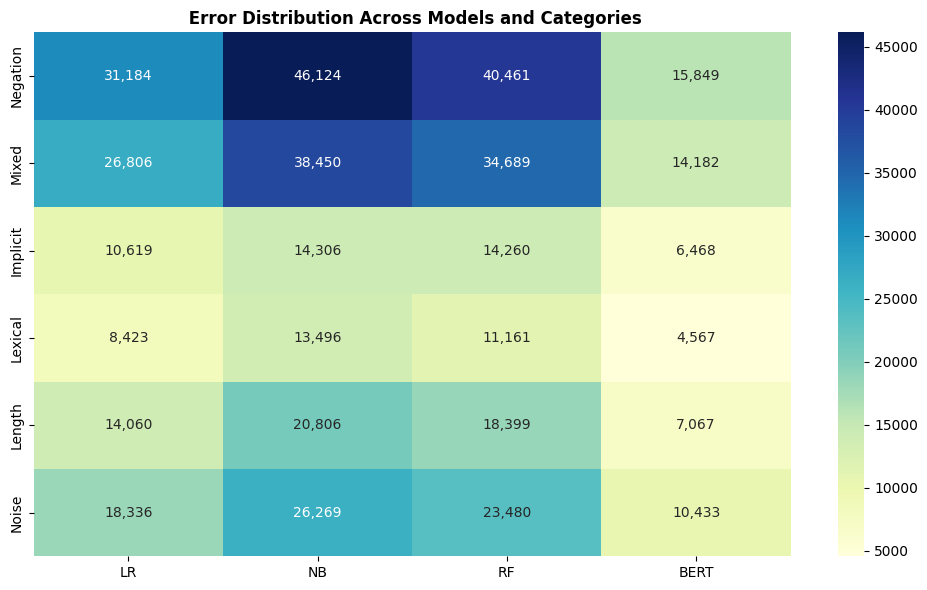

In [ ]:
data = {
    "LR": [31184, 26806, 10619, 8423, 14060, 18336],
    "NB": [46124, 38450, 14306, 13496, 20806, 26269],
    "RF": [40461, 34689, 14260, 11161, 18399, 23480],
    "BERT": [15849, 14182, 6468, 4567, 7067, 10433]
}

index = [
    "Negation",
    "Mixed",
    "Implicit",
    "Lexical",
    "Length",
    "Noise"
]

df = pd.DataFrame(data, index=index)

plt.figure(figsize=(10,6))

sns.heatmap(df, annot=True, fmt=",", cmap="YlGnBu")

plt.title(" Error Distribution Across Models and Categories", weight="bold")

plt.tight_layout()
plt.show()

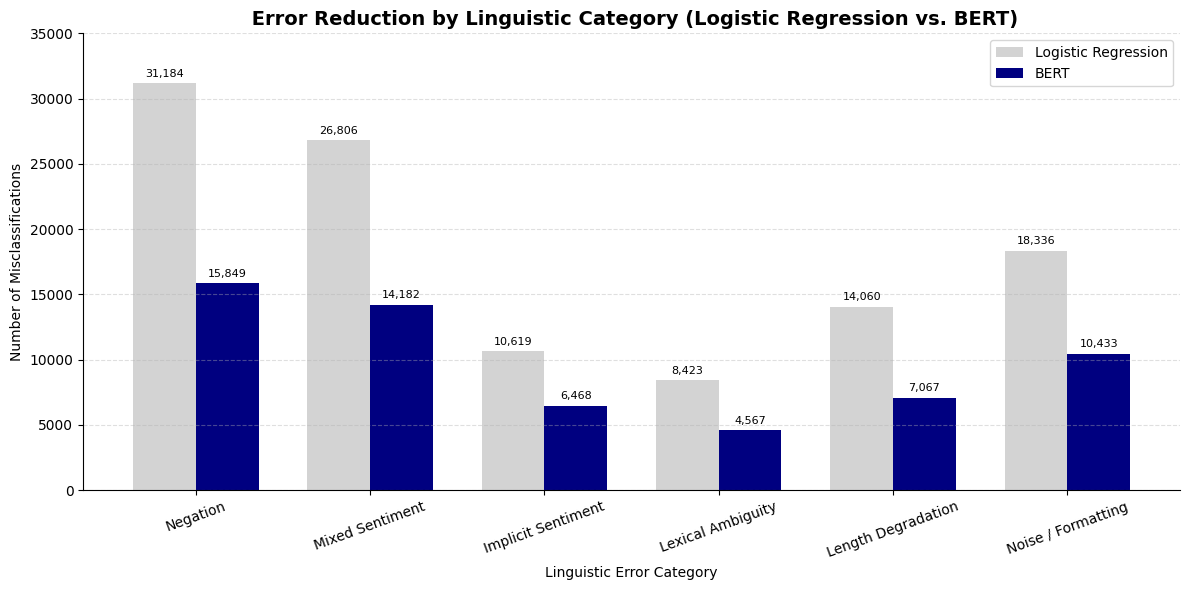

In [ ]:
categories = [
    "Negation",
    "Mixed Sentiment",
    "Implicit Sentiment",
    "Lexical Ambiguity",
    "Length Degradation",
    "Noise / Formatting"
]

logreg = [31184, 26806, 10619, 8423, 14060, 18336]
bert   = [15849, 14182, 6468, 4567, 7067, 10433]

x = np.arange(len(categories))
width = 0.36

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width/2,
    logreg,
    width,
    label="Logistic Regression",
    color="lightgrey"
)

bars2 = plt.bar(
    x + width/2,
    bert,
    width,
    label="BERT",
    color="navy"
)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 500,
            f"{int(height):,}",
            ha="center",
            fontsize=8
        )

plt.title(
    " Error Reduction by Linguistic Category (Logistic Regression vs. BERT)",
    fontsize=14,
    weight="bold"
)
plt.xlabel("Linguistic Error Category")
plt.ylabel("Number of Misclassifications")
plt.xticks(x, categories, rotation=20)
plt.ylim(0, 35000)

plt.legend(loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

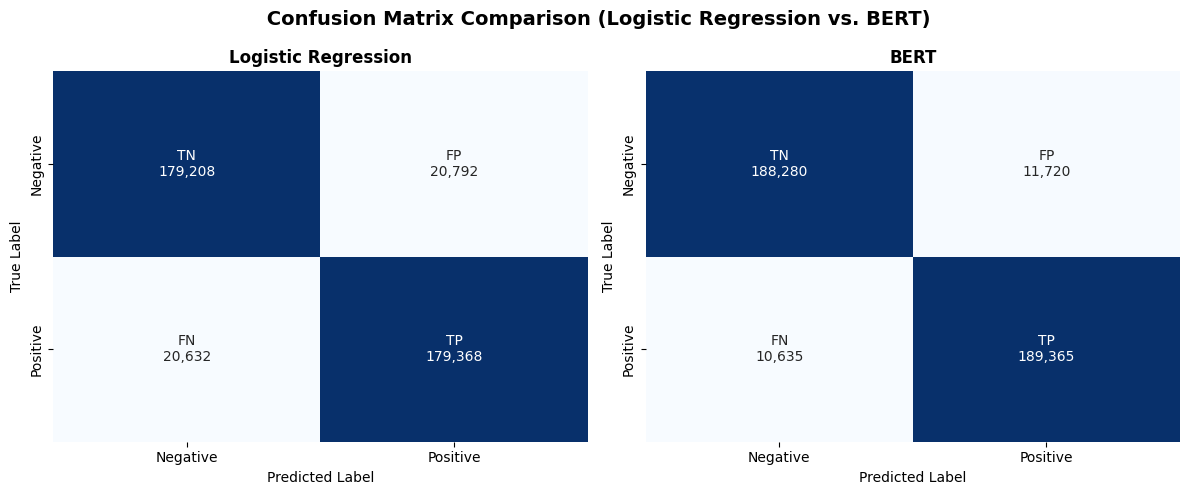

In [ ]:
cm_lr = np.array([
    [179208, 20792],
    [20632, 179368]
])

cm_bert = np.array([
    [188280, 11720],
    [10635, 189365]
])

labels = ["Negative", "Positive"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

annot_lr = np.array([
    [f"TN\n{179208:,}", f"FP\n{20792:,}"],
    [f"FN\n{20632:,}", f"TP\n{179368:,}"]
])

annot_bert = np.array([
    [f"TN\n{188280:,}", f"FP\n{11720:,}"],
    [f"FN\n{10635:,}", f"TP\n{189365:,}"]
])

sns.heatmap(
    cm_lr,
    annot=annot_lr,
    fmt="",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False,
    ax=axes[0]
)
axes[0].set_title("Logistic Regression", weight="bold")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(
    cm_bert,
    annot=annot_bert,
    fmt="",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False,
    ax=axes[1]
)
axes[1].set_title("BERT", weight="bold")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.suptitle(
    " Confusion Matrix Comparison (Logistic Regression vs. BERT)",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()
plt.show()

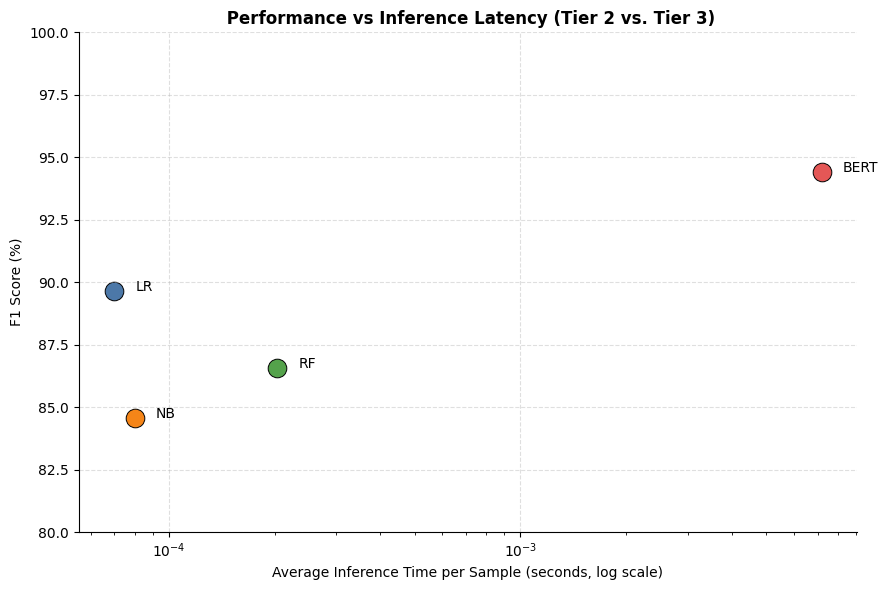

In [ ]:
df = pd.DataFrame({
    "Model": ["NB", "LR", "RF", "BERT"],
    "Latency": [0.000080, 0.000070, 0.000203, 0.007185],
    "F1": [0.845745, 0.896440, 0.865489, 0.944112]
})

colors = ["#F58518", "#4C78A8", "#54A24B", "#E45756"]

plt.figure(figsize=(9, 6))

for i in range(len(df)):
    plt.scatter(
        df["Latency"][i],
        df["F1"][i] * 100,
        s=180,
        color=colors[i],
        edgecolor="black",
        linewidth=0.7
    )
    plt.text(
        df["Latency"][i] * 1.15,
        df["F1"][i] * 100,
        df["Model"][i],
        fontsize=10
    )

plt.xscale("log")
plt.xlabel("Average Inference Time per Sample (seconds, log scale)")
plt.ylabel("F1 Score (%)")
plt.title(
    " Performance vs Inference Latency (Tier 2 vs. Tier 3)",
    weight="bold"
)

plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(80, 100)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

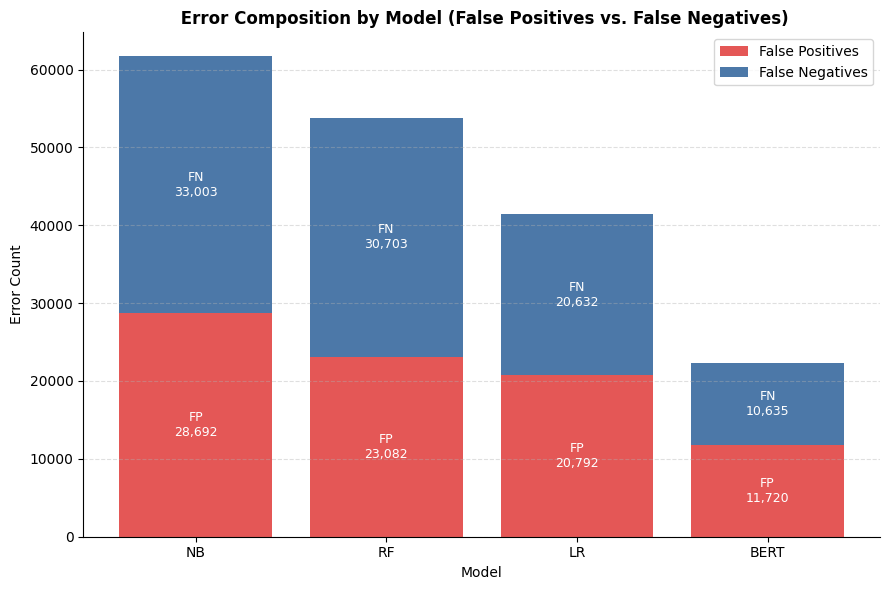

In [ ]:
models = ["NB", "RF", "LR", "BERT"]
fp = [28692, 23082, 20792, 11720]
fn = [33003, 30703, 20632, 10635]

x = np.arange(len(models))

plt.figure(figsize=(9, 6))

plt.bar(x, fp, label="False Positives", color="#E45756")
plt.bar(x, fn, bottom=fp, label="False Negatives", color="#4C78A8")

for i in range(len(models)):
    plt.text(i, fp[i]/2, f"FP\n{fp[i]:,}", ha="center", va="center", color="white", fontsize=9)
    plt.text(i, fp[i] + fn[i]/2, f"FN\n{fn[i]:,}", ha="center", va="center", color="white", fontsize=9)

plt.xticks(x, models)
plt.ylabel("Error Count")
plt.xlabel("Model")
plt.title(
    " Error Composition by Model (False Positives vs. False Negatives)",
    weight="bold"
)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()